In [1]:
# ==========================================================
# CELL 1
# Import all required libraries
# ==========================================================

print("Starting cell #1")

import os
import gc
import random
import math
import json
import warnings
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, Sampler
from torch.nn.utils import clip_grad_norm_

from transformers import (
    AutoTokenizer,
    XLMRobertaModel,
    XLMRobertaConfig,
    get_linear_schedule_with_warmup
)

from torch.optim import AdamW
from tqdm.auto import tqdm

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

print("Executed cell #1")

Starting cell #1
Executed cell #1


In [2]:
# ==========================================================
# CELL 2
# Set Kaggle dataset file names and dataset discovery hint
# ==========================================================

print("Starting cell #2")

TRAIN_FILE_NAME = "train.csv"
VALIDATION_FILE_NAME = "validation.csv"
TEST_FILE_NAME = "test.csv"

KAGGLE_INPUT_ROOT = "/kaggle/input"
DATASET_FOLDER_HINT = "Dataset"

print("Executed cell #2")

Starting cell #2
Executed cell #2


In [3]:
# ==========================================================
# CELL 3
# Set model hyperparameters, training settings, and save directory
# Teacher-student KD + full coverage then balanced SupCon
# ==========================================================

print("Starting cell #3")

# -----------------------------
# Backbone
# -----------------------------
TEACHER_MODEL_NAME = "xlm-roberta-base"

# -----------------------------
# Student architecture
# 6-layer student initialized from distributed teacher layers
# instead of only first 6 layers
# -----------------------------
STUDENT_NUM_LAYERS = 6
STUDENT_LAYER_SELECTION = [0, 2, 4, 6, 8, 11]

# -----------------------------
# Dataset columns
# Your original CSV columns are:
# Label, Bengali, Banglish, English
#
# After Cell 7 normalize_columns(), they become:
# label, bengali, banglish, english
# -----------------------------
LABEL_COLUMN = "label"
BANGLA_COLUMN = "bengali"
BANGLISH_COLUMN = "banglish"
ENGLISH_COLUMN = "english"

LANGUAGE_COLUMNS = [
    (BANGLA_COLUMN, "bengali"),
    (BANGLISH_COLUMN, "banglish"),
    (ENGLISH_COLUMN, "english")
]

NUM_LANGUAGES = 3

# -----------------------------
# General training
# -----------------------------
SEED = 42
MAX_LENGTH = 128

TEACHER_EPOCHS = 4
STUDENT_EPOCHS = 6

# First 2 epochs use normal full-coverage training.
# After that, balanced batches are used for stronger SupCon.
FULL_COVERAGE_EPOCHS = 2

TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 64
TEACHER_PRECOMPUTE_BATCH_SIZE = 64

GRADIENT_ACCUMULATION_STEPS = 1
GRAD_CLIP = 1.0

WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.10

LABEL_SMOOTHING = 0.05

# -----------------------------
# Learning rates
# -----------------------------
TEACHER_ENCODER_LR = 1e-5
TEACHER_HEAD_LR = 5e-5

STUDENT_ENCODER_LR = 2e-5
STUDENT_HEAD_LR = 7e-5

# -----------------------------
# Knowledge distillation
# -----------------------------
TEMPERATURE_KD = 2.0
ALPHA_KD = 0.40
DELTA_EMBED_KD = 0.10

# -----------------------------
# Contrastive losses
# -----------------------------
ROW_ALIGN_TEMPERATURE = 0.07
SUPCON_TEMPERATURE = 0.07

TEACHER_ROW_ALIGN_WEIGHT = 0.10
TEACHER_SUPCON_WEIGHT = 0.05

BETA_ROW_ALIGN = 0.10
GAMMA_SUPCON = 0.05

# -----------------------------
# Balanced batch setup
# Important for SupCon:
# each balanced batch contains multiple samples per class.
#
# You have 6 emotion classes.
# This makes each balanced batch:
# 6 classes x 3 samples per class = 18 original rows.
#
# Since each row has Bengali, Banglish, and English,
# the contrastive loss sees 18 x 3 = 54 sentence embeddings.
# -----------------------------
CLASSES_PER_BATCH = 6
SAMPLES_PER_CLASS = 3

BALANCED_BATCH_SIZE = CLASSES_PER_BATCH * SAMPLES_PER_CLASS

# -----------------------------
# Early stopping
# Macro-F1 is used because the dataset is class-imbalanced.
# -----------------------------
EARLY_STOPPING_PATIENCE = 2

# -----------------------------
# Save directory
# -----------------------------
SAVE_DIR = "/kaggle/working/emotion_kd_balanced_supcon"
os.makedirs(SAVE_DIR, exist_ok=True)

teacher_best_path = os.path.join(SAVE_DIR, "best_teacher.pt")
student_best_path = os.path.join(SAVE_DIR, "best_student.pt")

print("Executed cell #3")

Starting cell #3
Executed cell #3


In [4]:
# ==========================================================
# CELL 4
# Set random seeds for reproducibility
# ==========================================================

print("Starting cell #4")

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

torch.backends.cudnn.benchmark = True
torch.backends.cudnn.deterministic = False

print("Executed cell #4")

Starting cell #4
Executed cell #4


In [5]:
# ==========================================================
# CELL 5
# Check GPUs and configure AMP
# ==========================================================

print("Starting cell #5")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = torch.cuda.is_available()

print("Device:", device)

if torch.cuda.is_available():
    print("GPU count:", torch.cuda.device_count())
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}:", torch.cuda.get_device_name(i))

print("AMP enabled:", AMP_ENABLED)

print("Executed cell #5")

Starting cell #5
Device: cuda
GPU count: 2
GPU 0: Tesla T4
GPU 1: Tesla T4
AMP enabled: True
Executed cell #5


In [6]:
# ==========================================================
# CELL 6
# Resolve train, validation, and test CSV paths
# ==========================================================

print("Starting cell #6")

def find_file_in_kaggle(filename, root=KAGGLE_INPUT_ROOT):
    matches = []
    for dirpath, dirnames, filenames in os.walk(root):
        if filename in filenames:
            matches.append(os.path.join(dirpath, filename))

    if len(matches) == 0:
        raise FileNotFoundError(f"Could not find {filename} under {root}")

    # Prefer folders containing Dataset if available
    preferred = [m for m in matches if DATASET_FOLDER_HINT.lower() in m.lower()]
    if preferred:
        return preferred[0]

    return matches[0]


train_path = find_file_in_kaggle(TRAIN_FILE_NAME)
validation_path = find_file_in_kaggle(VALIDATION_FILE_NAME)
test_path = find_file_in_kaggle(TEST_FILE_NAME)

print("Train path:", train_path)
print("Validation path:", validation_path)
print("Test path:", test_path)

print("Executed cell #6")

Starting cell #6
Train path: /kaggle/input/datasets/sajedulislamsajid/dataset/train.csv
Validation path: /kaggle/input/datasets/sajedulislamsajid/dataset/validation.csv
Test path: /kaggle/input/datasets/sajedulislamsajid/dataset/test.csv
Executed cell #6


In [7]:
# ==========================================================
# CELL 7
# Load datasets and normalize column names
# ==========================================================

print("Starting cell #7")

def normalize_columns(df):
    df = df.copy()
    df.columns = [str(c).strip().lower() for c in df.columns]
    return df


def load_csv(path):
    df = pd.read_csv(path)
    df = normalize_columns(df)
    return df


train_df = load_csv(train_path)
val_df = load_csv(validation_path)
test_df = load_csv(test_path)

required_columns = [LABEL_COLUMN, BANGLA_COLUMN, BANGLISH_COLUMN, ENGLISH_COLUMN]

for col in required_columns:
    if col not in train_df.columns:
        raise ValueError(f"Missing column in train.csv: {col}")
    if col not in val_df.columns:
        raise ValueError(f"Missing column in validation.csv: {col}")
    if col not in test_df.columns:
        raise ValueError(f"Missing column in test.csv: {col}")

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("Train columns:", train_df.columns.tolist())

print("Executed cell #7")

Starting cell #7
Train shape: (56067, 4)
Validation shape: (7929, 4)
Test shape: (16101, 4)
Train columns: ['label', 'bengali', 'banglish', 'english']
Executed cell #7


In [8]:
# ==========================================================
# CELL 8
# Encode emotion labels and build class weights for imbalance
# ==========================================================

print("Starting cell #8")

label_encoder = LabelEncoder()
label_encoder.fit(train_df[LABEL_COLUMN].astype(str))

train_df["label_id"] = label_encoder.transform(train_df[LABEL_COLUMN].astype(str))
val_df["label_id"] = label_encoder.transform(val_df[LABEL_COLUMN].astype(str))
test_df["label_id"] = label_encoder.transform(test_df[LABEL_COLUMN].astype(str))

id2label = {i: label for i, label in enumerate(label_encoder.classes_)}
label2id = {label: i for i, label in id2label.items()}

NUM_LABELS = len(label_encoder.classes_)

print("Emotion classes:")
for i, label in id2label.items():
    print(i, "->", label)

class_counts = train_df["label_id"].value_counts().sort_index()
print("\nClass counts:")
print(class_counts)

# Effective class weights:
# total / (num_classes * class_count)
total_samples = len(train_df)
class_weights = []

for class_id in range(NUM_LABELS):
    count = class_counts.get(class_id, 1)
    weight = total_samples / (NUM_LABELS * count)
    class_weights.append(weight)

class_weights = torch.tensor(class_weights, dtype=torch.float)

print("\nClass weights:")
for i, w in enumerate(class_weights.tolist()):
    print(id2label[i], ":", round(w, 4))

print("Executed cell #8")

Starting cell #8
Emotion classes:
0 -> anger
1 -> disgust
2 -> fear
3 -> joy
4 -> sadness
5 -> surprise

Class counts:
label_id
0    10626
1     9169
2     5295
3    12486
4    11416
5     7075
Name: count, dtype: int64

Class weights:
anger : 0.8794
disgust : 1.0191
fear : 1.7648
joy : 0.7484
sadness : 0.8185
surprise : 1.3208
Executed cell #8


In [9]:
# ==========================================================
# CELL 9
# Build flat classification dataframe and triplet dataframe
# ==========================================================

print("Starting cell #9")

def build_flat_dataframe(df):
    rows = []

    for _, row in df.iterrows():
        label_id = int(row["label_id"])

        for text_col, lang_name in LANGUAGE_COLUMNS:
            rows.append({
                "text": str(row[text_col]),
                "label_id": label_id,
                "language": lang_name
            })

    return pd.DataFrame(rows)


def build_triplet_dataframe(df):
    rows = []

    for row_id, row in df.reset_index(drop=True).iterrows():
        rows.append({
            "row_id": row_id,
            "bangla": str(row[BANGLA_COLUMN]),
            "banglish": str(row[BANGLISH_COLUMN]),
            "english": str(row[ENGLISH_COLUMN]),
            "label_id": int(row["label_id"])
        })

    return pd.DataFrame(rows)


flat_train_df = build_flat_dataframe(train_df)
flat_val_df = build_flat_dataframe(val_df)
flat_test_df = build_flat_dataframe(test_df)

triplet_train_df = build_triplet_dataframe(train_df)
triplet_val_df = build_triplet_dataframe(val_df)
triplet_test_df = build_triplet_dataframe(test_df)

print("Flat train shape:", flat_train_df.shape)
print("Triplet train shape:", triplet_train_df.shape)

print("Executed cell #9")

Starting cell #9
Flat train shape: (168201, 3)
Triplet train shape: (56067, 5)
Executed cell #9


In [10]:
# ==========================================================
# CELL 10
# Load tokenizer
# ==========================================================

print("Starting cell #10")

tokenizer = AutoTokenizer.from_pretrained(TEACHER_MODEL_NAME)

print("Tokenizer vocab size:", tokenizer.vocab_size)

print("Executed cell #10")

Starting cell #10


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer vocab size: 250002
Executed cell #10


In [11]:
# ==========================================================
# CELL 11
# Define flat and triplet datasets
# ==========================================================

print("Starting cell #11")

class FlatEmotionDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        return {
            "text": row["text"],
            "labels": int(row["label_id"]),
            "language": row["language"]
        }


class TripletEmotionDataset(Dataset):
    def __init__(
        self,
        dataframe,
        teacher_logits_bangla=None,
        teacher_logits_banglish=None,
        teacher_logits_english=None,
        teacher_emb_bangla=None,
        teacher_emb_banglish=None,
        teacher_emb_english=None
    ):
        self.df = dataframe.reset_index(drop=True)

        self.teacher_logits_bangla = teacher_logits_bangla
        self.teacher_logits_banglish = teacher_logits_banglish
        self.teacher_logits_english = teacher_logits_english

        self.teacher_emb_bangla = teacher_emb_bangla
        self.teacher_emb_banglish = teacher_emb_banglish
        self.teacher_emb_english = teacher_emb_english

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        item = {
            "bangla": row["bangla"],
            "banglish": row["banglish"],
            "english": row["english"],
            "labels": int(row["label_id"]),
            "row_id": int(row["row_id"])
        }

        if self.teacher_logits_bangla is not None:
            item["teacher_logits_bangla"] = self.teacher_logits_bangla[idx]
            item["teacher_logits_banglish"] = self.teacher_logits_banglish[idx]
            item["teacher_logits_english"] = self.teacher_logits_english[idx]

        if self.teacher_emb_bangla is not None:
            item["teacher_emb_bangla"] = self.teacher_emb_bangla[idx]
            item["teacher_emb_banglish"] = self.teacher_emb_banglish[idx]
            item["teacher_emb_english"] = self.teacher_emb_english[idx]

        return item


print("Executed cell #11")

Starting cell #11
Executed cell #11


In [12]:
# ==========================================================
# CELL 12
# Define dynamic padding collators
# ==========================================================

print("Starting cell #12")

class FlatCollator:
    def __init__(self, tokenizer, max_length):
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __call__(self, batch):
        texts = [item["text"] for item in batch]
        labels = torch.tensor([item["labels"] for item in batch], dtype=torch.long)

        encoded = self.tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

        encoded["labels"] = labels
        return encoded


class TripletCollator:
    def __init__(self, tokenizer, max_length):
        self.tokenizer = tokenizer
        self.max_length = max_length

    def encode_texts(self, texts):
        return self.tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

    def __call__(self, batch):
        bangla_texts = [item["bangla"] for item in batch]
        banglish_texts = [item["banglish"] for item in batch]
        english_texts = [item["english"] for item in batch]

        labels = torch.tensor([item["labels"] for item in batch], dtype=torch.long)
        row_ids = torch.tensor([item["row_id"] for item in batch], dtype=torch.long)

        bangla_encoded = self.encode_texts(bangla_texts)
        banglish_encoded = self.encode_texts(banglish_texts)
        english_encoded = self.encode_texts(english_texts)

        output = {
            "bangla_input_ids": bangla_encoded["input_ids"],
            "bangla_attention_mask": bangla_encoded["attention_mask"],

            "banglish_input_ids": banglish_encoded["input_ids"],
            "banglish_attention_mask": banglish_encoded["attention_mask"],

            "english_input_ids": english_encoded["input_ids"],
            "english_attention_mask": english_encoded["attention_mask"],

            "labels": labels,
            "row_ids": row_ids
        }

        if "teacher_logits_bangla" in batch[0]:
            output["teacher_logits_bangla"] = torch.stack(
                [item["teacher_logits_bangla"] for item in batch]
            )
            output["teacher_logits_banglish"] = torch.stack(
                [item["teacher_logits_banglish"] for item in batch]
            )
            output["teacher_logits_english"] = torch.stack(
                [item["teacher_logits_english"] for item in batch]
            )

        if "teacher_emb_bangla" in batch[0]:
            output["teacher_emb_bangla"] = torch.stack(
                [item["teacher_emb_bangla"] for item in batch]
            )
            output["teacher_emb_banglish"] = torch.stack(
                [item["teacher_emb_banglish"] for item in batch]
            )
            output["teacher_emb_english"] = torch.stack(
                [item["teacher_emb_english"] for item in batch]
            )

        return output


flat_collator = FlatCollator(tokenizer, MAX_LENGTH)
triplet_collator = TripletCollator(tokenizer, MAX_LENGTH)

print("Executed cell #12")

Starting cell #12
Executed cell #12


In [13]:
# ==========================================================
# CELL 13
# Define balanced batch sampler for SupCon
# First 2 epochs use full coverage; later epochs use this sampler
# ==========================================================

print("Starting cell #13")

class BalancedClassBatchSampler(Sampler):
    """
    Creates balanced batches for supervised contrastive learning.

    Each batch contains:
        classes_per_batch classes
        samples_per_class rows from each class

    Since class counts are imbalanced, minority classes are sampled with replacement.
    This is used only after the first full-coverage epochs.
    """

    def __init__(
        self,
        labels,
        classes_per_batch,
        samples_per_class,
        num_batches=None,
        seed=42
    ):
        self.labels = np.array(labels)
        self.classes_per_batch = classes_per_batch
        self.samples_per_class = samples_per_class
        self.batch_size = classes_per_batch * samples_per_class
        self.seed = seed

        self.class_to_indices = defaultdict(list)
        for idx, label in enumerate(self.labels):
            self.class_to_indices[int(label)].append(idx)

        self.classes = sorted(list(self.class_to_indices.keys()))

        if classes_per_batch > len(self.classes):
            raise ValueError("classes_per_batch cannot exceed number of classes")

        if num_batches is None:
            self.num_batches = math.ceil(len(self.labels) / self.batch_size)
        else:
            self.num_batches = num_batches

    def __len__(self):
        return self.num_batches

    def __iter__(self):
        rng = np.random.default_rng(self.seed + random.randint(0, 10_000_000))

        for _ in range(self.num_batches):
            selected_classes = rng.choice(
                self.classes,
                size=self.classes_per_batch,
                replace=False
            )

            batch_indices = []

            for class_id in selected_classes:
                indices = self.class_to_indices[int(class_id)]

                replace_needed = len(indices) < self.samples_per_class

                chosen = rng.choice(
                    indices,
                    size=self.samples_per_class,
                    replace=replace_needed
                )

                batch_indices.extend(chosen.tolist())

            rng.shuffle(batch_indices)
            yield batch_indices


print("Executed cell #13")

Starting cell #13
Executed cell #13


In [14]:
# ==========================================================
# CELL 14
# Build dataset objects and dataloaders
# Full coverage loader + balanced SupCon loader
# ==========================================================

print("Starting cell #14")

flat_train_dataset = FlatEmotionDataset(flat_train_df)
flat_val_dataset = FlatEmotionDataset(flat_val_df)
flat_test_dataset = FlatEmotionDataset(flat_test_df)

triplet_train_dataset_no_teacher = TripletEmotionDataset(triplet_train_df)
triplet_val_dataset = TripletEmotionDataset(triplet_val_df)
triplet_test_dataset = TripletEmotionDataset(triplet_test_df)

flat_train_loader = DataLoader(
    flat_train_dataset,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    collate_fn=flat_collator,
    num_workers=2,
    pin_memory=True
)

flat_val_loader = DataLoader(
    flat_val_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    collate_fn=flat_collator,
    num_workers=2,
    pin_memory=True
)

flat_test_loader = DataLoader(
    flat_test_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    collate_fn=flat_collator,
    num_workers=2,
    pin_memory=True
)

# Full coverage triplet loader:
# every row appears once per epoch
triplet_train_full_loader_no_teacher = DataLoader(
    triplet_train_dataset_no_teacher,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    collate_fn=triplet_collator,
    num_workers=2,
    pin_memory=True
)

# Balanced triplet loader:
# used after first 2 epochs
balanced_sampler_no_teacher = BalancedClassBatchSampler(
    labels=triplet_train_df["label_id"].tolist(),
    classes_per_batch=CLASSES_PER_BATCH,
    samples_per_class=SAMPLES_PER_CLASS,
    seed=SEED
)

triplet_train_balanced_loader_no_teacher = DataLoader(
    triplet_train_dataset_no_teacher,
    batch_sampler=balanced_sampler_no_teacher,
    collate_fn=triplet_collator,
    num_workers=2,
    pin_memory=True
)

triplet_val_loader = DataLoader(
    triplet_val_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    collate_fn=triplet_collator,
    num_workers=2,
    pin_memory=True
)

triplet_test_loader = DataLoader(
    triplet_test_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    collate_fn=triplet_collator,
    num_workers=2,
    pin_memory=True
)

print("Flat train batches:", len(flat_train_loader))
print("Triplet full coverage train batches:", len(triplet_train_full_loader_no_teacher))
print("Triplet balanced train batches:", len(triplet_train_balanced_loader_no_teacher))

print("Executed cell #14")

Starting cell #14
Flat train batches: 10513
Triplet full coverage train batches: 3505
Triplet balanced train batches: 3115
Executed cell #14


In [15]:
# ==========================================================
# CELL 15
# Define mean pooling and emotion model
# Teacher: full XLM-R
# Student: 6-layer XLM-R initialized from selected teacher layers
# ==========================================================

print("Starting cell #15")

def mean_pooling(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).type_as(last_hidden_state)
    summed = torch.sum(last_hidden_state * mask, dim=1)
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / counts


class XLMREmotionModel(nn.Module):
    def __init__(
        self,
        model_name,
        num_labels,
        dropout=0.20,
        student_layers=None
    ):
        super().__init__()

        self.encoder = XLMRobertaModel.from_pretrained(
            model_name,
            add_pooling_layer=False
        )

        if student_layers is not None:
            original_layers = list(self.encoder.encoder.layer)

            selected_layers = []
            for layer_idx in student_layers:
                selected_layers.append(original_layers[layer_idx])

            self.encoder.encoder.layer = nn.ModuleList(selected_layers)
            self.encoder.config.num_hidden_layers = len(selected_layers)

        hidden_size = self.encoder.config.hidden_size

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, num_labels)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True
        )

        embeddings = mean_pooling(
            outputs.last_hidden_state,
            attention_mask
        )

        logits = self.classifier(self.dropout(embeddings))

        return {
            "embeddings": embeddings,
            "logits": logits
        }


def get_base_model(model):
    if isinstance(model, nn.DataParallel):
        return model.module
    return model


def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


print("Executed cell #15")

Starting cell #15
Executed cell #15


In [16]:
# ==========================================================
# CELL 16
# Initialize teacher and student models
# ==========================================================

print("Starting cell #16")

teacher_model = XLMREmotionModel(
    model_name=TEACHER_MODEL_NAME,
    num_labels=NUM_LABELS,
    dropout=0.20,
    student_layers=None
)

student_model = XLMREmotionModel(
    model_name=TEACHER_MODEL_NAME,
    num_labels=NUM_LABELS,
    dropout=0.20,
    student_layers=STUDENT_LAYER_SELECTION
)

teacher_model.to(device)
student_model.to(device)

if torch.cuda.device_count() > 1:
    print("Using DataParallel for teacher and student.")
    teacher_model = nn.DataParallel(teacher_model)
    student_model = nn.DataParallel(student_model)

print("Teacher trainable params:", count_trainable_parameters(teacher_model))
print("Student trainable params:", count_trainable_parameters(student_model))

print("Executed cell #16")

Starting cell #16


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                         | Status     |  | 
----------------------------+------------+--+-
lm_head.layer_norm.weight   | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 
lm_head.layer_norm.bias     | UNEXPECTED |  | 
lm_head.dense.bias          | UNEXPECTED |  | 
lm_head.bias                | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 
lm_head.dense.weight        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                         | Status     |  | 
----------------------------+------------+--+-
lm_head.layer_norm.weight   | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 
lm_head.layer_norm.bias     | UNEXPECTED |  | 
lm_head.dense.bias          | UNEXPECTED |  | 
lm_head.bias                | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 
lm_head.dense.weight        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Using DataParallel for teacher and student.
Teacher trainable params: 277457670
Student trainable params: 234930438
Executed cell #16


In [17]:
# ==========================================================
# CELL 17
# Define weighted CE, KD, embedding KD, row alignment, and SupCon losses
# ==========================================================

print("Starting cell #17")

classification_criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(device),
    label_smoothing=LABEL_SMOOTHING
)


def knowledge_distillation_loss(student_logits, teacher_logits, temperature=2.0):
    student_logits = student_logits.float()
    teacher_logits = teacher_logits.float().detach()

    student_log_probs = F.log_softmax(student_logits / temperature, dim=-1)
    teacher_probs = F.softmax(teacher_logits / temperature, dim=-1)

    loss = F.kl_div(
        student_log_probs,
        teacher_probs,
        reduction="batchmean"
    ) * (temperature ** 2)

    return loss


def embedding_distillation_loss(student_embeddings, teacher_embeddings):
    student_embeddings = F.normalize(student_embeddings.float(), p=2, dim=1)
    teacher_embeddings = F.normalize(teacher_embeddings.float().detach(), p=2, dim=1)

    cosine_sim = F.cosine_similarity(
        student_embeddings,
        teacher_embeddings,
        dim=1
    )

    return (1.0 - cosine_sim).mean()


class MultiPositiveRowAlignmentLoss(nn.Module):
    """
    Positives:
    Bangla_i, Banglish_i, English_i from the same original row.
    """

    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, emb_bangla, emb_banglish, emb_english):
        embeddings = torch.cat(
            [emb_bangla, emb_banglish, emb_english],
            dim=0
        )

        embeddings = F.normalize(embeddings.float(), p=2, dim=1)

        batch_size = emb_bangla.size(0)
        device_local = embeddings.device

        row_ids = torch.arange(batch_size, device=device_local).repeat(3)

        sim_matrix = torch.matmul(embeddings, embeddings.T) / self.temperature
        sim_matrix = sim_matrix - sim_matrix.max(dim=1, keepdim=True).values.detach()

        self_mask = torch.eye(
            sim_matrix.size(0),
            dtype=torch.bool,
            device=device_local
        )

        positive_mask = (
            row_ids.unsqueeze(0) == row_ids.unsqueeze(1)
        ) & (~self_mask)

        exp_sim = torch.exp(sim_matrix) * (~self_mask).float()

        log_prob = sim_matrix - torch.log(
            exp_sim.sum(dim=1, keepdim=True) + 1e-12
        )

        positive_mask_float = positive_mask.float()

        positive_count = positive_mask_float.sum(dim=1)

        valid_anchor_mask = positive_count > 0

        mean_log_prob_pos = (
            (positive_mask_float * log_prob).sum(dim=1) /
            positive_count.clamp(min=1.0)
        )

        loss = -mean_log_prob_pos[valid_anchor_mask].mean()

        return loss


class SupervisedContrastiveLoss(nn.Module):
    """
    Positives:
    samples with same emotion label.

    This works best when each batch has multiple samples per class.
    That is why balanced batches are used after first 2 full-coverage epochs.
    """

    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, embeddings, labels):
        embeddings = F.normalize(embeddings.float(), p=2, dim=1)
        labels = labels.contiguous().view(-1)

        device_local = embeddings.device
        n = embeddings.size(0)

        sim_matrix = torch.matmul(embeddings, embeddings.T) / self.temperature
        sim_matrix = sim_matrix - sim_matrix.max(dim=1, keepdim=True).values.detach()

        self_mask = torch.eye(n, dtype=torch.bool, device=device_local)

        positive_mask = (
            labels.unsqueeze(0) == labels.unsqueeze(1)
        ) & (~self_mask)

        exp_sim = torch.exp(sim_matrix) * (~self_mask).float()

        log_prob = sim_matrix - torch.log(
            exp_sim.sum(dim=1, keepdim=True) + 1e-12
        )

        positive_mask_float = positive_mask.float()
        positive_count = positive_mask_float.sum(dim=1)

        valid_anchor_mask = positive_count > 0

        if valid_anchor_mask.sum() == 0:
            return torch.tensor(0.0, device=device_local, requires_grad=True)

        mean_log_prob_pos = (
            (positive_mask_float * log_prob).sum(dim=1) /
            positive_count.clamp(min=1.0)
        )

        loss = -mean_log_prob_pos[valid_anchor_mask].mean()

        return loss


row_alignment_criterion = MultiPositiveRowAlignmentLoss(
    temperature=ROW_ALIGN_TEMPERATURE
)

supcon_criterion = SupervisedContrastiveLoss(
    temperature=SUPCON_TEMPERATURE
)

print("Executed cell #17")

Starting cell #17
Executed cell #17


In [18]:
# ==========================================================
# CELL 18
# Define optimizer helper with separate encoder/head learning rates
# ==========================================================

print("Starting cell #18")

def build_optimizer(model, encoder_lr, head_lr):
    base_model = get_base_model(model)

    encoder_named_params = []
    head_named_params = []

    for name, param in base_model.named_parameters():
        if not param.requires_grad:
            continue

        if name.startswith("encoder."):
            encoder_named_params.append((name, param))
        else:
            head_named_params.append((name, param))

    no_decay_terms = ["bias", "LayerNorm.weight", "LayerNorm.bias"]

    def build_groups(named_params, lr):
        decay_params = []
        no_decay_params = []

        for name, param in named_params:
            if any(term in name for term in no_decay_terms):
                no_decay_params.append(param)
            else:
                decay_params.append(param)

        groups = []

        if decay_params:
            groups.append({
                "params": decay_params,
                "lr": lr,
                "weight_decay": WEIGHT_DECAY
            })

        if no_decay_params:
            groups.append({
                "params": no_decay_params,
                "lr": lr,
                "weight_decay": 0.0
            })

        return groups

    optimizer = AdamW(
        build_groups(encoder_named_params, encoder_lr) +
        build_groups(head_named_params, head_lr)
    )

    return optimizer


print("Executed cell #18")

Starting cell #18
Executed cell #18


In [19]:
# ==========================================================
# CELL 19
# Define evaluation function
# Evaluates flat text classification over all languages
# ==========================================================

print("Starting cell #19")

@torch.inference_mode()
def evaluate_model(model, data_loader):
    model.eval()

    all_preds = []
    all_labels = []

    for batch in tqdm(data_loader, desc="Evaluating", leave=False):
        input_ids = batch["input_ids"].to(device, non_blocking=True)
        attention_mask = batch["attention_mask"].to(device, non_blocking=True)
        labels = batch["labels"].to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=AMP_ENABLED):
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs["logits"]

        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_labels.extend(labels.detach().cpu().numpy().tolist())

    accuracy = accuracy_score(all_labels, all_preds)

    precision_macro, recall_macro, macro_f1, _ = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    precision_weighted, recall_weighted, weighted_f1, _ = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "macro_f1": macro_f1,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "weighted_f1": weighted_f1,
        "preds": all_preds,
        "labels": all_labels
    }


print("Executed cell #19")

Starting cell #19
Executed cell #19


In [20]:
# ==========================================================
# CELL 20
# Train teacher with CE + row alignment + SupCon
# First 2 epochs: full coverage
# Later epochs: balanced batches for stronger SupCon
# ==========================================================

print("Starting cell #20")

teacher_optimizer = build_optimizer(
    teacher_model,
    encoder_lr=TEACHER_ENCODER_LR,
    head_lr=TEACHER_HEAD_LR
)

teacher_steps_per_epoch = max(
    len(triplet_train_full_loader_no_teacher),
    len(triplet_train_balanced_loader_no_teacher)
)

teacher_total_steps = teacher_steps_per_epoch * TEACHER_EPOCHS

teacher_scheduler = get_linear_schedule_with_warmup(
    teacher_optimizer,
    num_warmup_steps=int(WARMUP_RATIO * teacher_total_steps),
    num_training_steps=teacher_total_steps
)

teacher_scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)

best_teacher_f1 = -1.0
teacher_epochs_without_improvement = 0

for epoch in range(TEACHER_EPOCHS):
    teacher_model.train()

    if epoch < FULL_COVERAGE_EPOCHS:
        current_loader = triplet_train_full_loader_no_teacher
        stage_name = "full_coverage"
    else:
        current_loader = triplet_train_balanced_loader_no_teacher
        stage_name = "balanced_supcon"

    total_loss_meter = 0.0
    ce_loss_meter = 0.0
    row_loss_meter = 0.0
    supcon_loss_meter = 0.0

    progress_bar = tqdm(
        current_loader,
        desc=f"Teacher Epoch {epoch + 1}/{TEACHER_EPOCHS} [{stage_name}]",
        leave=True
    )

    for batch in progress_bar:
        labels = batch["labels"].to(device, non_blocking=True)

        bangla_input_ids = batch["bangla_input_ids"].to(device, non_blocking=True)
        bangla_attention_mask = batch["bangla_attention_mask"].to(device, non_blocking=True)

        banglish_input_ids = batch["banglish_input_ids"].to(device, non_blocking=True)
        banglish_attention_mask = batch["banglish_attention_mask"].to(device, non_blocking=True)

        english_input_ids = batch["english_input_ids"].to(device, non_blocking=True)
        english_attention_mask = batch["english_attention_mask"].to(device, non_blocking=True)

        teacher_optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=AMP_ENABLED):
            out_bangla = teacher_model(
                input_ids=bangla_input_ids,
                attention_mask=bangla_attention_mask
            )

            out_banglish = teacher_model(
                input_ids=banglish_input_ids,
                attention_mask=banglish_attention_mask
            )

            out_english = teacher_model(
                input_ids=english_input_ids,
                attention_mask=english_attention_mask
            )

            logits_all = torch.cat([
                out_bangla["logits"],
                out_banglish["logits"],
                out_english["logits"]
            ], dim=0)

            embeddings_all = torch.cat([
                out_bangla["embeddings"],
                out_banglish["embeddings"],
                out_english["embeddings"]
            ], dim=0)

            labels_all = labels.repeat(3)

            ce_loss = classification_criterion(
                logits_all.float(),
                labels_all
            )

            row_loss = row_alignment_criterion(
                out_bangla["embeddings"],
                out_banglish["embeddings"],
                out_english["embeddings"]
            )

            supcon_loss = supcon_criterion(
                embeddings_all,
                labels_all
            )

            total_loss = (
                ce_loss
                + TEACHER_ROW_ALIGN_WEIGHT * row_loss
                + TEACHER_SUPCON_WEIGHT * supcon_loss
            )

        teacher_scaler.scale(total_loss).backward()
        teacher_scaler.unscale_(teacher_optimizer)
        clip_grad_norm_(teacher_model.parameters(), GRAD_CLIP)
        teacher_scaler.step(teacher_optimizer)
        teacher_scaler.update()
        teacher_scheduler.step()

        total_loss_meter += total_loss.item()
        ce_loss_meter += ce_loss.item()
        row_loss_meter += row_loss.item()
        supcon_loss_meter += supcon_loss.item()

        progress_bar.set_postfix({
            "total": f"{total_loss.item():.4f}",
            "ce": f"{ce_loss.item():.4f}",
            "row": f"{row_loss.item():.4f}",
            "supcon": f"{supcon_loss.item():.4f}"
        })

    val_metrics = evaluate_model(teacher_model, flat_val_loader)

    print(f"\n===== Teacher Epoch {epoch + 1}/{TEACHER_EPOCHS} =====")
    print("Training stage:", stage_name)
    print("Train total loss:", round(total_loss_meter / len(current_loader), 4))
    print("Train CE loss:", round(ce_loss_meter / len(current_loader), 4))
    print("Train row alignment loss:", round(row_loss_meter / len(current_loader), 4))
    print("Train SupCon loss:", round(supcon_loss_meter / len(current_loader), 4))
    print("Validation Accuracy:", round(val_metrics["accuracy"], 4))
    print("Validation Macro F1:", round(val_metrics["macro_f1"], 4))
    print("Validation Weighted F1:", round(val_metrics["weighted_f1"], 4))

    if val_metrics["macro_f1"] > best_teacher_f1:
        best_teacher_f1 = val_metrics["macro_f1"]
        teacher_epochs_without_improvement = 0

        torch.save(
            get_base_model(teacher_model).state_dict(),
            teacher_best_path
        )

        print("Best teacher saved:", teacher_best_path)

    else:
        teacher_epochs_without_improvement += 1
        print(
            "No teacher improvement:",
            teacher_epochs_without_improvement,
            "/",
            EARLY_STOPPING_PATIENCE
        )

    if teacher_epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print("Early stopping teacher training.")
        break

get_base_model(teacher_model).load_state_dict(
    torch.load(teacher_best_path, map_location=device)
)

teacher_model.eval()

for p in teacher_model.parameters():
    p.requires_grad = False

print("Best teacher validation macro F1:", best_teacher_f1)
print("Teacher frozen.")

print("Executed cell #20")

Starting cell #20


Teacher Epoch 1/4 [full_coverage]:   0%|          | 0/3505 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/372 [00:00<?, ?it/s]


===== Teacher Epoch 1/4 =====
Training stage: full_coverage
Train total loss: 1.782
Train CE loss: 1.3815
Train row alignment loss: 2.0
Train SupCon loss: 4.0115
Validation Accuracy: 0.5684
Validation Macro F1: 0.5648
Validation Weighted F1: 0.5651
Best teacher saved: /kaggle/working/emotion_kd_balanced_supcon/best_teacher.pt


Teacher Epoch 2/4 [full_coverage]:   0%|          | 0/3505 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/372 [00:00<?, ?it/s]


===== Teacher Epoch 3/4 =====
Training stage: balanced_supcon
Train total loss: 1.299
Train CE loss: 0.9717
Train row alignment loss: 1.3101
Train SupCon loss: 3.9251
Validation Accuracy: 0.6037
Validation Macro F1: 0.5976
Validation Weighted F1: 0.6016
Best teacher saved: /kaggle/working/emotion_kd_balanced_supcon/best_teacher.pt


Teacher Epoch 4/4 [balanced_supcon]:   0%|          | 0/3115 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/372 [00:00<?, ?it/s]


===== Teacher Epoch 4/4 =====
Training stage: balanced_supcon
Train total loss: 1.2496
Train CE loss: 0.9273
Train row alignment loss: 1.284
Train SupCon loss: 3.8788
Validation Accuracy: 0.6098
Validation Macro F1: 0.6029
Validation Weighted F1: 0.6075
Best teacher saved: /kaggle/working/emotion_kd_balanced_supcon/best_teacher.pt
Best teacher validation macro F1: 0.6029451042003002
Teacher frozen.
Executed cell #20


In [21]:
# ==========================================================
# CELL 21
# Precompute teacher logits and embeddings for student KD
# Includes both logit KD and embedding KD
# ==========================================================

print("Starting cell #21")

@torch.inference_mode()
def precompute_teacher_outputs(model, dataset, batch_size):
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=triplet_collator,
        num_workers=2,
        pin_memory=True
    )

    model.eval()

    all_logits_bangla = []
    all_logits_banglish = []
    all_logits_english = []

    all_emb_bangla = []
    all_emb_banglish = []
    all_emb_english = []

    for batch in tqdm(loader, desc="Precomputing teacher outputs", leave=True):
        bangla_input_ids = batch["bangla_input_ids"].to(device, non_blocking=True)
        bangla_attention_mask = batch["bangla_attention_mask"].to(device, non_blocking=True)

        banglish_input_ids = batch["banglish_input_ids"].to(device, non_blocking=True)
        banglish_attention_mask = batch["banglish_attention_mask"].to(device, non_blocking=True)

        english_input_ids = batch["english_input_ids"].to(device, non_blocking=True)
        english_attention_mask = batch["english_attention_mask"].to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=AMP_ENABLED):
            out_bangla = model(
                input_ids=bangla_input_ids,
                attention_mask=bangla_attention_mask
            )

            out_banglish = model(
                input_ids=banglish_input_ids,
                attention_mask=banglish_attention_mask
            )

            out_english = model(
                input_ids=english_input_ids,
                attention_mask=english_attention_mask
            )

        all_logits_bangla.append(out_bangla["logits"].detach().cpu().to(torch.float16))
        all_logits_banglish.append(out_banglish["logits"].detach().cpu().to(torch.float16))
        all_logits_english.append(out_english["logits"].detach().cpu().to(torch.float16))

        all_emb_bangla.append(out_bangla["embeddings"].detach().cpu().to(torch.float16))
        all_emb_banglish.append(out_banglish["embeddings"].detach().cpu().to(torch.float16))
        all_emb_english.append(out_english["embeddings"].detach().cpu().to(torch.float16))

    return {
        "logits_bangla": torch.cat(all_logits_bangla, dim=0),
        "logits_banglish": torch.cat(all_logits_banglish, dim=0),
        "logits_english": torch.cat(all_logits_english, dim=0),

        "emb_bangla": torch.cat(all_emb_bangla, dim=0),
        "emb_banglish": torch.cat(all_emb_banglish, dim=0),
        "emb_english": torch.cat(all_emb_english, dim=0)
    }


train_teacher_outputs = precompute_teacher_outputs(
    model=teacher_model,
    dataset=triplet_train_dataset_no_teacher,
    batch_size=TEACHER_PRECOMPUTE_BATCH_SIZE
)

triplet_train_dataset = TripletEmotionDataset(
    triplet_train_df,
    teacher_logits_bangla=train_teacher_outputs["logits_bangla"],
    teacher_logits_banglish=train_teacher_outputs["logits_banglish"],
    teacher_logits_english=train_teacher_outputs["logits_english"],
    teacher_emb_bangla=train_teacher_outputs["emb_bangla"],
    teacher_emb_banglish=train_teacher_outputs["emb_banglish"],
    teacher_emb_english=train_teacher_outputs["emb_english"]
)

triplet_train_full_loader = DataLoader(
    triplet_train_dataset,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    collate_fn=triplet_collator,
    num_workers=2,
    pin_memory=True
)

balanced_sampler = BalancedClassBatchSampler(
    labels=triplet_train_df["label_id"].tolist(),
    classes_per_batch=CLASSES_PER_BATCH,
    samples_per_class=SAMPLES_PER_CLASS,
    seed=SEED
)

triplet_train_balanced_loader = DataLoader(
    triplet_train_dataset,
    batch_sampler=balanced_sampler,
    collate_fn=triplet_collator,
    num_workers=2,
    pin_memory=True
)

print("Student full coverage batches:", len(triplet_train_full_loader))
print("Student balanced batches:", len(triplet_train_balanced_loader))

print("Executed cell #21")

Starting cell #21


Precomputing teacher outputs:   0%|          | 0/877 [00:00<?, ?it/s]

Student full coverage batches: 3505
Student balanced batches: 3115
Executed cell #21


In [22]:
# ==========================================================
# CELL 22
# Train student with CE + logit KD + embedding KD + row alignment + SupCon
# First 2 epochs: full coverage
# Later epochs: balanced batches for SupCon
# ==========================================================

print("Starting cell #22")

student_optimizer = build_optimizer(
    student_model,
    encoder_lr=STUDENT_ENCODER_LR,
    head_lr=STUDENT_HEAD_LR
)

student_steps_per_epoch = max(
    len(triplet_train_full_loader),
    len(triplet_train_balanced_loader)
)

student_total_steps = student_steps_per_epoch * STUDENT_EPOCHS

student_scheduler = get_linear_schedule_with_warmup(
    student_optimizer,
    num_warmup_steps=int(WARMUP_RATIO * student_total_steps),
    num_training_steps=student_total_steps
)

student_scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)

best_student_f1 = -1.0
student_epochs_without_improvement = 0

for epoch in range(STUDENT_EPOCHS):
    student_model.train()

    if epoch < FULL_COVERAGE_EPOCHS:
        current_loader = triplet_train_full_loader
        stage_name = "full_coverage"
    else:
        current_loader = triplet_train_balanced_loader
        stage_name = "balanced_supcon"

    # Loss schedule
    if epoch == 0:
        kd_weight = 0.20
        embed_kd_weight = 0.05
        row_weight = 0.00
        supcon_weight = 0.00
    elif epoch == 1:
        kd_weight = ALPHA_KD
        embed_kd_weight = DELTA_EMBED_KD
        row_weight = BETA_ROW_ALIGN * 0.50
        supcon_weight = GAMMA_SUPCON * 0.50
    else:
        kd_weight = ALPHA_KD
        embed_kd_weight = DELTA_EMBED_KD
        row_weight = BETA_ROW_ALIGN
        supcon_weight = GAMMA_SUPCON

    total_meter = 0.0
    ce_meter = 0.0
    kd_meter = 0.0
    emb_kd_meter = 0.0
    row_meter = 0.0
    supcon_meter = 0.0

    progress_bar = tqdm(
        current_loader,
        desc=f"Student Epoch {epoch + 1}/{STUDENT_EPOCHS} [{stage_name}]",
        leave=True
    )

    for batch in progress_bar:
        labels = batch["labels"].to(device, non_blocking=True)

        bangla_input_ids = batch["bangla_input_ids"].to(device, non_blocking=True)
        bangla_attention_mask = batch["bangla_attention_mask"].to(device, non_blocking=True)

        banglish_input_ids = batch["banglish_input_ids"].to(device, non_blocking=True)
        banglish_attention_mask = batch["banglish_attention_mask"].to(device, non_blocking=True)

        english_input_ids = batch["english_input_ids"].to(device, non_blocking=True)
        english_attention_mask = batch["english_attention_mask"].to(device, non_blocking=True)

        teacher_logits_bangla = batch["teacher_logits_bangla"].to(device, non_blocking=True)
        teacher_logits_banglish = batch["teacher_logits_banglish"].to(device, non_blocking=True)
        teacher_logits_english = batch["teacher_logits_english"].to(device, non_blocking=True)

        teacher_emb_bangla = batch["teacher_emb_bangla"].to(device, non_blocking=True)
        teacher_emb_banglish = batch["teacher_emb_banglish"].to(device, non_blocking=True)
        teacher_emb_english = batch["teacher_emb_english"].to(device, non_blocking=True)

        student_optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=AMP_ENABLED):
            out_bangla = student_model(
                input_ids=bangla_input_ids,
                attention_mask=bangla_attention_mask
            )

            out_banglish = student_model(
                input_ids=banglish_input_ids,
                attention_mask=banglish_attention_mask
            )

            out_english = student_model(
                input_ids=english_input_ids,
                attention_mask=english_attention_mask
            )

            student_logits_all = torch.cat([
                out_bangla["logits"],
                out_banglish["logits"],
                out_english["logits"]
            ], dim=0)

            teacher_logits_all = torch.cat([
                teacher_logits_bangla,
                teacher_logits_banglish,
                teacher_logits_english
            ], dim=0)

            student_emb_all = torch.cat([
                out_bangla["embeddings"],
                out_banglish["embeddings"],
                out_english["embeddings"]
            ], dim=0)

            teacher_emb_all = torch.cat([
                teacher_emb_bangla,
                teacher_emb_banglish,
                teacher_emb_english
            ], dim=0)

            labels_all = labels.repeat(3)

            ce_loss = classification_criterion(
                student_logits_all.float(),
                labels_all
            )

            kd_loss = knowledge_distillation_loss(
                student_logits_all,
                teacher_logits_all,
                temperature=TEMPERATURE_KD
            )

            emb_kd_loss = embedding_distillation_loss(
                student_emb_all,
                teacher_emb_all
            )

            row_loss = row_alignment_criterion(
                out_bangla["embeddings"],
                out_banglish["embeddings"],
                out_english["embeddings"]
            )

            supcon_loss = supcon_criterion(
                student_emb_all,
                labels_all
            )

            total_loss = (
                ce_loss
                + kd_weight * kd_loss
                + embed_kd_weight * emb_kd_loss
                + row_weight * row_loss
                + supcon_weight * supcon_loss
            )

        student_scaler.scale(total_loss).backward()
        student_scaler.unscale_(student_optimizer)
        clip_grad_norm_(student_model.parameters(), GRAD_CLIP)
        student_scaler.step(student_optimizer)
        student_scaler.update()
        student_scheduler.step()

        total_meter += total_loss.item()
        ce_meter += ce_loss.item()
        kd_meter += kd_loss.item()
        emb_kd_meter += emb_kd_loss.item()
        row_meter += row_loss.item()
        supcon_meter += supcon_loss.item()

        progress_bar.set_postfix({
            "total": f"{total_loss.item():.4f}",
            "ce": f"{ce_loss.item():.4f}",
            "kd": f"{kd_loss.item():.4f}",
            "emb_kd": f"{emb_kd_loss.item():.4f}",
            "row": f"{row_loss.item():.4f}",
            "supcon": f"{supcon_loss.item():.4f}"
        })

    val_metrics = evaluate_model(student_model, flat_val_loader)

    print(f"\n===== Student Epoch {epoch + 1}/{STUDENT_EPOCHS} =====")
    print("Training stage:", stage_name)
    print("KD weight:", kd_weight)
    print("Embedding KD weight:", embed_kd_weight)
    print("Row alignment weight:", row_weight)
    print("SupCon weight:", supcon_weight)
    print("Train total loss:", round(total_meter / len(current_loader), 4))
    print("Train CE loss:", round(ce_meter / len(current_loader), 4))
    print("Train KD loss:", round(kd_meter / len(current_loader), 4))
    print("Train embedding KD loss:", round(emb_kd_meter / len(current_loader), 4))
    print("Train row alignment loss:", round(row_meter / len(current_loader), 4))
    print("Train SupCon loss:", round(supcon_meter / len(current_loader), 4))
    print("Validation Accuracy:", round(val_metrics["accuracy"], 4))
    print("Validation Macro F1:", round(val_metrics["macro_f1"], 4))
    print("Validation Weighted F1:", round(val_metrics["weighted_f1"], 4))

    if val_metrics["macro_f1"] > best_student_f1:
        best_student_f1 = val_metrics["macro_f1"]
        student_epochs_without_improvement = 0

        torch.save(
            get_base_model(student_model).state_dict(),
            student_best_path
        )

        print("Best student saved:", student_best_path)

    else:
        student_epochs_without_improvement += 1
        print(
            "No student improvement:",
            student_epochs_without_improvement,
            "/",
            EARLY_STOPPING_PATIENCE
        )

    if student_epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print("Early stopping student training.")
        break

get_base_model(student_model).load_state_dict(
    torch.load(student_best_path, map_location=device)
)

print("Best student validation macro F1:", best_student_f1)

print("Executed cell #22")

Starting cell #22


Student Epoch 1/6 [full_coverage]:   0%|          | 0/3505 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/372 [00:00<?, ?it/s]


===== Student Epoch 1/6 =====
Training stage: full_coverage
KD weight: 0.2
Embedding KD weight: 0.05
Row alignment weight: 0.0
SupCon weight: 0.0
Train total loss: 1.6358
Train CE loss: 1.4475
Train KD loss: 0.804
Train embedding KD loss: 0.5481
Train row alignment loss: 3.7251
Train SupCon loss: 4.8715
Validation Accuracy: 0.5447
Validation Macro F1: 0.5351
Validation Weighted F1: 0.5375
Best student saved: /kaggle/working/emotion_kd_balanced_supcon/best_student.pt


Student Epoch 2/6 [full_coverage]:   0%|          | 0/3505 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/372 [00:00<?, ?it/s]


===== Student Epoch 5/6 =====
Training stage: balanced_supcon
KD weight: 0.4
Embedding KD weight: 0.1
Row alignment weight: 0.1
SupCon weight: 0.05
Train total loss: 1.3368
Train CE loss: 0.9021
Train KD loss: 0.2043
Train embedding KD loss: 0.2463
Train row alignment loss: 1.3855
Train SupCon loss: 3.7968
Validation Accuracy: 0.6143
Validation Macro F1: 0.6092
Validation Weighted F1: 0.6136
Best student saved: /kaggle/working/emotion_kd_balanced_supcon/best_student.pt


Student Epoch 6/6 [balanced_supcon]:   0%|          | 0/3115 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/372 [00:00<?, ?it/s]


===== Student Epoch 6/6 =====
Training stage: balanced_supcon
KD weight: 0.4
Embedding KD weight: 0.1
Row alignment weight: 0.1
SupCon weight: 0.05
Train total loss: 1.2958
Train CE loss: 0.8698
Train KD loss: 0.1942
Train embedding KD loss: 0.2387
Train row alignment loss: 1.3607
Train SupCon loss: 3.7674
Validation Accuracy: 0.6156
Validation Macro F1: 0.61
Validation Weighted F1: 0.6149
Best student saved: /kaggle/working/emotion_kd_balanced_supcon/best_student.pt
Best student validation macro F1: 0.6100292050559674
Executed cell #22


In [23]:
# ==========================================================
# CELL 23
# Evaluate best student on test set
# ==========================================================

print("Starting cell #23")

test_metrics = evaluate_model(student_model, flat_test_loader)

print("\n===== Final Student Test Results =====")
print("Test Accuracy:", round(test_metrics["accuracy"], 4))
print("Test Macro Precision:", round(test_metrics["precision_macro"], 4))
print("Test Macro Recall:", round(test_metrics["recall_macro"], 4))
print("Test Macro F1:", round(test_metrics["macro_f1"], 4))
print("Test Weighted F1:", round(test_metrics["weighted_f1"], 4))

target_names = [id2label[i] for i in range(NUM_LABELS)]

print("\nClassification Report:")
print(
    classification_report(
        test_metrics["labels"],
        test_metrics["preds"],
        target_names=target_names,
        zero_division=0
    )
)

print("Executed cell #23")

Starting cell #23


Evaluating:   0%|          | 0/755 [00:00<?, ?it/s]


===== Final Student Test Results =====
Test Accuracy: 0.6073
Test Macro Precision: 0.5983
Test Macro Recall: 0.6203
Test Macro F1: 0.6017
Test Weighted F1: 0.6067

Classification Report:
              precision    recall  f1-score   support

       anger       0.52      0.45      0.48      9153
     disgust       0.53      0.61      0.57      7899
        fear       0.51      0.74      0.61      4563
         joy       0.82      0.74      0.78     10755
     sadness       0.64      0.49      0.56      9837
    surprise       0.56      0.68      0.61      6096

    accuracy                           0.61     48303
   macro avg       0.60      0.62      0.60     48303
weighted avg       0.62      0.61      0.61     48303

Executed cell #23


Starting cell #24


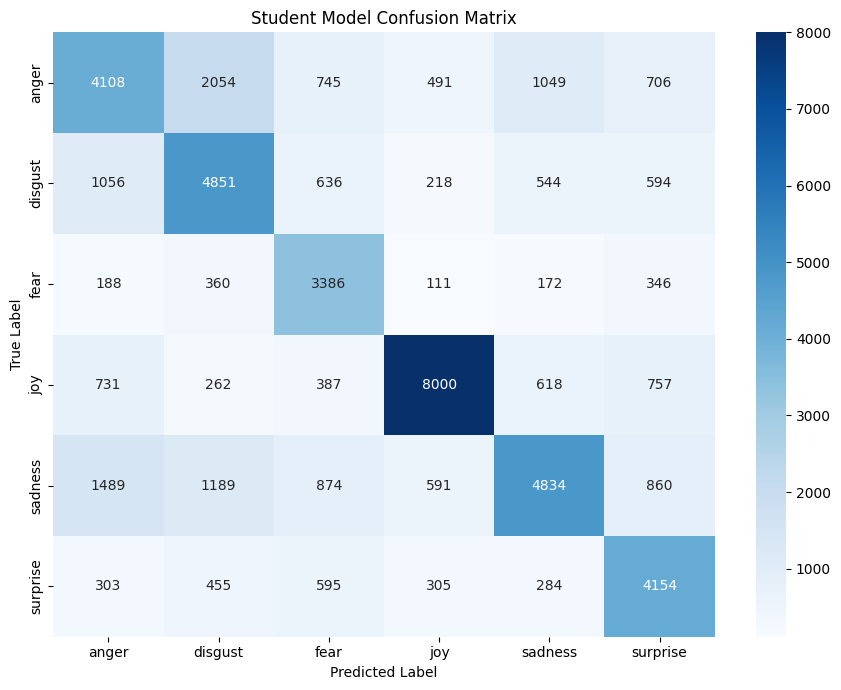

Executed cell #24


In [24]:
# ==========================================================
# CELL 24
# Plot confusion matrix
# ==========================================================

print("Starting cell #24")

cm = confusion_matrix(
    test_metrics["labels"],
    test_metrics["preds"]
)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=target_names,
    yticklabels=target_names,
    cmap="Blues"
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Student Model Confusion Matrix")
plt.tight_layout()
plt.show()

print("Executed cell #24")

In [25]:
# ==========================================================
# CELL 25
# Save final student model, tokenizer, label mapping, and config
# ==========================================================

print("Starting cell #25")

final_student_dir = os.path.join(SAVE_DIR, "final_student_model")
os.makedirs(final_student_dir, exist_ok=True)

base_student = get_base_model(student_model)

torch.save(
    base_student.state_dict(),
    os.path.join(final_student_dir, "student_model_state_dict.pt")
)

tokenizer.save_pretrained(final_student_dir)

config = {
    "teacher_model_name": TEACHER_MODEL_NAME,
    "num_labels": NUM_LABELS,
    "id2label": id2label,
    "label2id": label2id,
    "max_length": MAX_LENGTH,
    "student_num_layers": STUDENT_NUM_LAYERS,
    "student_layer_selection": STUDENT_LAYER_SELECTION,
    "label_smoothing": LABEL_SMOOTHING,
    "temperature_kd": TEMPERATURE_KD,
    "row_align_temperature": ROW_ALIGN_TEMPERATURE,
    "supcon_temperature": SUPCON_TEMPERATURE,
    "class_weights": class_weights.tolist()
}

with open(os.path.join(final_student_dir, "training_config.json"), "w") as f:
    json.dump(config, f, indent=2)

print("Saved final student model to:", final_student_dir)

print("Executed cell #25")

Starting cell #25
Saved final student model to: /kaggle/working/emotion_kd_balanced_supcon/final_student_model
Executed cell #25
